In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [8]:
df = pd.read_csv('data/listings.csv', low_memory=False)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 22,770
Columnas: 90


In [9]:
df.head(3)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20260330062416,2026-04-01,city scrape,Villa,"Dentro de Villa un estudio de arte con futon, ...",NaN,https://a0.muscache.com/pictures/f395ab78-1185...,153786,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
1,70644,https://www.airbnb.com/rooms/70644,20260330062416,2026-04-02,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,NaN,https://a0.muscache.com/pictures/f397d2da-d045...,212109,...,4.98,4.96,4.91,NaN,NaN,1,1,0,0,0.83
2,245507,https://www.airbnb.com/rooms/245507,20260330062416,2026-04-03,city scrape,Reforma Ave area / US Embassy / walk everywhere,"THE APARTMENT IS LOCATED IN A PRIME LOCATION, ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1288063,...,4.94,4.89,4.83,NaN,NaN,4,4,0,0,2.36


In [10]:
columnas_importantes = [
    'id', 'name', 'neighbourhood_cleansed', 'room_type',
    'price', 'minimum_nights', 'number_of_reviews',
    'review_scores_rating', 'latitude', 'longitude',
    'availability_365'
]

df[columnas_importantes].head(5)

,id,name,neighbourhood_cleansed,room_type,price,minimum_nights,number_of_reviews,review_scores_rating,latitude,longitude,availability_365
0,35797,Villa,Cuajimalpa de Morelos,Private room,"$10,412.00",1.0,0,NaN,19.38283,-99.27178,363
1,70644,Beautiful light Studio Coyoacan- full equipped !,Coyoacán,Entire home/apt,"$2,317.67",3.0,142,4.91,19.35448,-99.16217,247
2,245507,Reforma Ave area / US Embassy / walk everywhere,Cuauhtémoc,Entire home/apt,"$1,642.00",1.0,415,4.85,19.42360,-99.16979,222
3,247543,"Independent studio, top location",Cuauhtémoc,Entire home/apt,"$1,107.00",3.0,174,4.91,19.43516,-99.13806,138
4,261897,Charming 1 bedroom loft w/ balcony in Roma/con...,Cuauhtémoc,Entire home/apt,"$2,847.20",5.0,363,4.77,19.41877,-99.17199,167


In [11]:
print("=== TIPOS DE DATOS ===")
print(df[columnas_importantes].dtypes)

print("\n=== VALORES NULOS (%) ===")
nulos = df[columnas_importantes].isnull().mean() * 100
print(nulos.round(1))


=== TIPOS DE DATOS ===
id                          int64
name                          str
neighbourhood_cleansed        str
room_type                     str
price                         str
minimum_nights            float64
number_of_reviews           int64
review_scores_rating      float64
latitude                  float64
longitude                 float64
availability_365            int64
dtype: object

=== VALORES NULOS (%) ===
id                        0.0
name                      0.0
neighbourhood_cleansed    0.0
room_type                 0.0
price                     1.8
minimum_nights            0.0
number_of_reviews         0.0
review_scores_rating      9.9
latitude                  0.0
longitude                 0.0
availability_365          0.0
dtype: float64


In [12]:
# Primero veamos cómo viene el precio original
print(df['price'].head(10))
print(f"\nTipo de dato: {df['price'].dtype}")

0    $10,412.00
1     $2,317.67
2     $1,642.00
3     $1,107.00
4     $2,847.20
5       $832.00
6       $975.67
7     $1,870.67
8    $15,000.00
9       $433.00
Name: price, dtype: str

Tipo de dato: str


In [13]:
# Quitamos el símbolo $ y las comas, luego convertimos a float
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)   # elimina el $
    .str.replace(',', '', regex=False)   # elimina las comas de miles
    .astype(float)                        # convierte a número decimal
)

print(f"✅ Tipo de dato ahora: {df['price'].dtype}")
print(f"Precio promedio: ${df['price'].mean():,.0f} MXN")
print(f"Precio mínimo:   ${df['price'].min():,.0f} MXN")
print(f"Precio máximo:   ${df['price'].max():,.0f} MXN")

✅ Tipo de dato ahora: float64
Precio promedio: $2,400 MXN
Precio mínimo:   $120 MXN
Precio máximo:   $1,268,544 MXN


In [14]:
print(f"Filas antes del filtro: {len(df):,}")

# Filtramos: precio mayor a 0 y menor a 20,000 MXN/noche
df = df[(df['price'] > 0) & (df['price'] < 20000)]

print(f"Filas después del filtro: {len(df):,}")
print(f"Registros eliminados: {21438 - len(df):,}")

Filas antes del filtro: 22,770
Filas después del filtro: 22,256
Registros eliminados: -818


In [15]:
# Rellenamos rating con la mediana (más robusta que el promedio ante outliers)
mediana_rating = df['review_scores_rating'].median()
df['review_scores_rating'] = df['review_scores_rating'].fillna(mediana_rating)

# Columnas de texto: nulos → "Sin dato"
df['name'] = df['name'].fillna('Sin dato')

print(f"Mediana de rating usada para rellenar: {mediana_rating:.1f}")
print(f"\nNulos restantes en columnas clave:")
print(df[['price', 'review_scores_rating', 'name', 'neighbourhood_cleansed']].isnull().sum())

Mediana de rating usada para rellenar: 4.8

Nulos restantes en columnas clave:
price                     0
review_scores_rating      0
name                      0
neighbourhood_cleansed    0
dtype: int64


In [16]:
columnas_finales = [
    'id',
    'name',
    'neighbourhood_cleansed',   # colonia/alcaldía
    'room_type',                 # tipo de cuarto
    'price',                     # precio por noche (ya limpio)
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'latitude',
    'longitude',
    'availability_365',          # días disponibles al año
    'calculated_host_listings_count'  # cuántas propiedades tiene el anfitrión
]

df_clean = df[columnas_finales].copy()

print(f"Shape final: {df_clean.shape}")
print(f"\nPrimeras filas del df limpio:")
df_clean.head(3)

Shape final: (22256, 12)

Primeras filas del df limpio:


,id,name,neighbourhood_cleansed,room_type,price,minimum_nights,number_of_reviews,review_scores_rating,latitude,longitude,availability_365,calculated_host_listings_count
0,35797,Villa,Cuajimalpa de Morelos,Private room,10412.00,1.0,0,4.84,19.38283,-99.27178,363,1
1,70644,Beautiful light Studio Coyoacan- full equipped !,Coyoacán,Entire home/apt,2317.67,3.0,142,4.91,19.35448,-99.16217,247,1
2,245507,Reforma Ave area / US Embassy / walk everywhere,Cuauhtémoc,Entire home/apt,1642.00,1.0,415,4.85,19.42360,-99.16979,222,4


In [17]:
print("=" * 45)
print("      REPORTE DE SALUD DEL DATASET")
print("=" * 45)
print(f"  Filas totales:        {len(df_clean):>10,}")
print(f"  Columnas:             {df_clean.shape[1]:>10}")
print(f"  Valores nulos:        {df_clean.isnull().sum().sum():>10}")
print(f"  Precio promedio:      ${df_clean['price'].mean():>9,.0f} MXN")
print(f"  Precio mediana:       ${df_clean['price'].median():>9,.0f} MXN")
print(f"  Tipos de cuarto:      {df_clean['room_type'].nunique():>10}")
print(f"  Colonias únicas:      {df_clean['neighbourhood_cleansed'].nunique():>10}")
print("=" * 45)

      REPORTE DE SALUD DEL DATASET
  Filas totales:            22,256
  Columnas:                     12
  Valores nulos:                 5
  Precio promedio:      $    2,076 MXN
  Precio mediana:       $    1,558 MXN
  Tipos de cuarto:               4
  Colonias únicas:              16


In [18]:
df_clean.to_csv('data/listings_clean.csv', index=False)
print("✅ Dataset limpio guardado en data/listings_clean.csv")

✅ Dataset limpio guardado en data/listings_clean.csv


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si estás en un notebook nuevo, carga el CSV limpio
df = pd.read_csv('data/listings_clean.csv')

# Estilo global para todas las gráficas
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print(f"✅ Dataset cargado: {df.shape[0]:,} listings")

✅ Dataset cargado: 22,256 listings


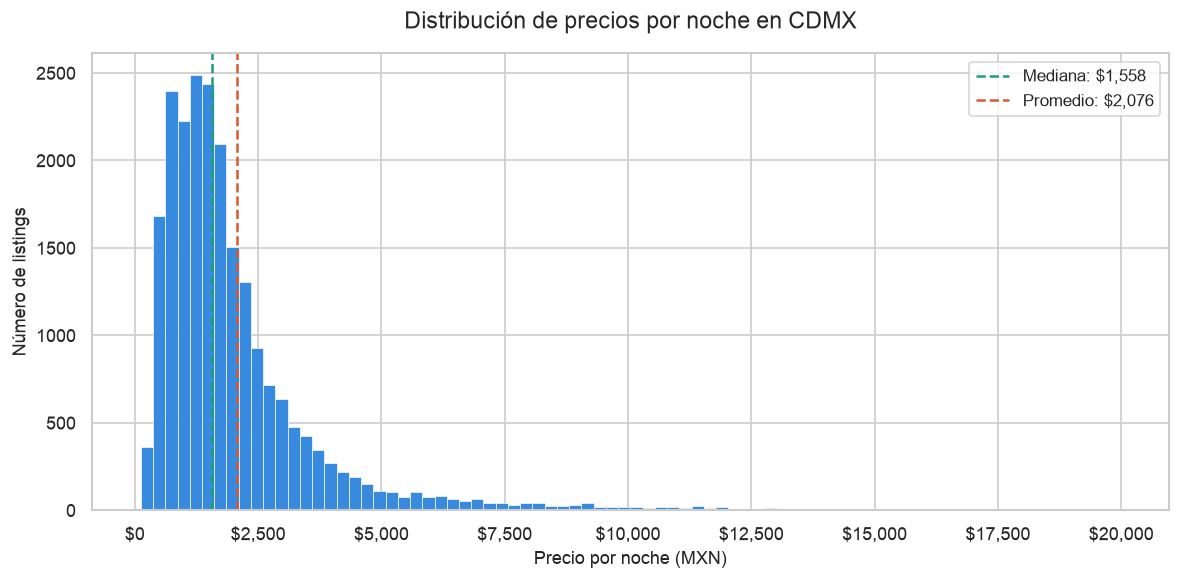


Insight: El 75% de los listings cuesta menos de $2,397 MXN/noche


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['price'], bins=80, color='#378ADD', edgecolor='white', linewidth=0.4)

ax.set_title('Distribución de precios por noche en CDMX', fontsize=14, pad=15)
ax.set_xlabel('Precio por noche (MXN)', fontsize=11)
ax.set_ylabel('Número de listings', fontsize=11)

# Líneas de referencia: mediana y promedio
mediana = df['price'].median()
promedio = df['price'].mean()

ax.axvline(mediana, color='#1D9E75', linestyle='--', linewidth=1.5, label=f'Mediana: ${mediana:,.0f}')
ax.axvline(promedio, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Promedio: ${promedio:,.0f}')

ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('graficas/01_distribucion_precios.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nInsight: El 75% de los listings cuesta menos de ${df['price'].quantile(0.75):,.0f} MXN/noche")

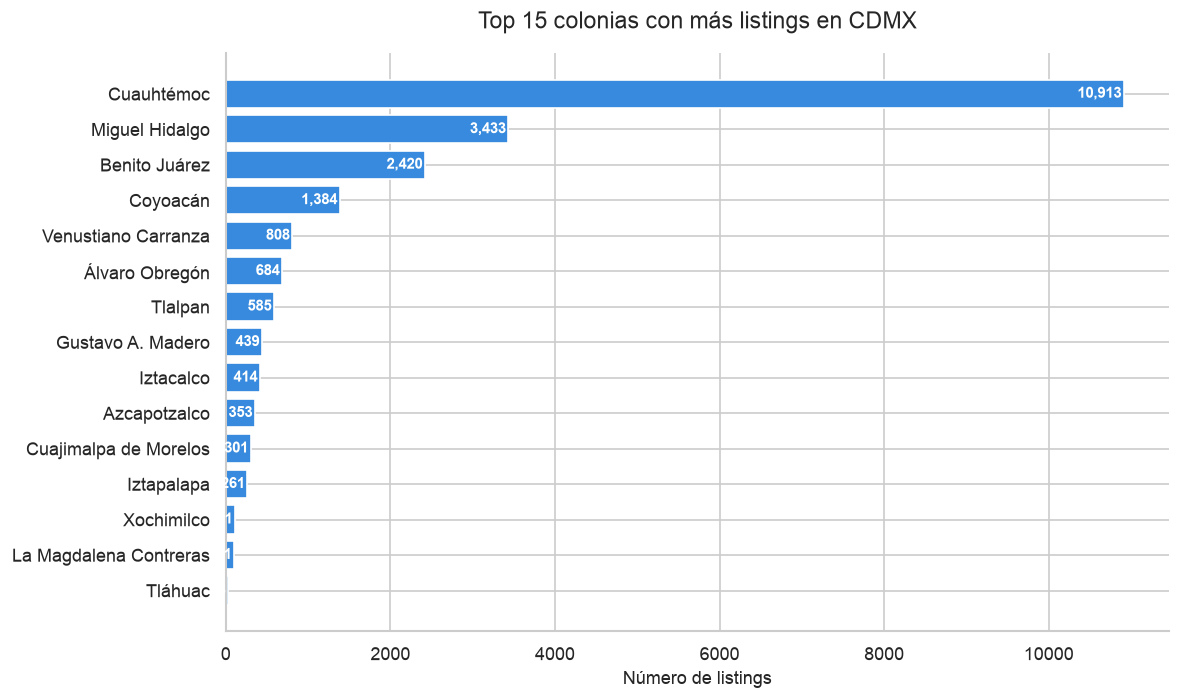

In [21]:
top_colonias = (df['neighbourhood_cleansed']
                .value_counts()
                .head(15))

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top_colonias.index[::-1], top_colonias.values[::-1], color='#378ADD')

# Etiquetas con el número dentro de cada barra
for bar, val in zip(bars, top_colonias.values[::-1]):
    ax.text(bar.get_width() - 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='right', fontsize=9,
            color='white', fontweight='bold')

ax.set_title('Top 15 colonias con más listings en CDMX', fontsize=14, pad=15)
ax.set_xlabel('Número de listings', fontsize=11)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('graficas/02_top_colonias.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/7p/ph22603x7yg_d90xh_yjchk40000gn/T/ipykernel_8023/2688788257.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='room_type', y='price',


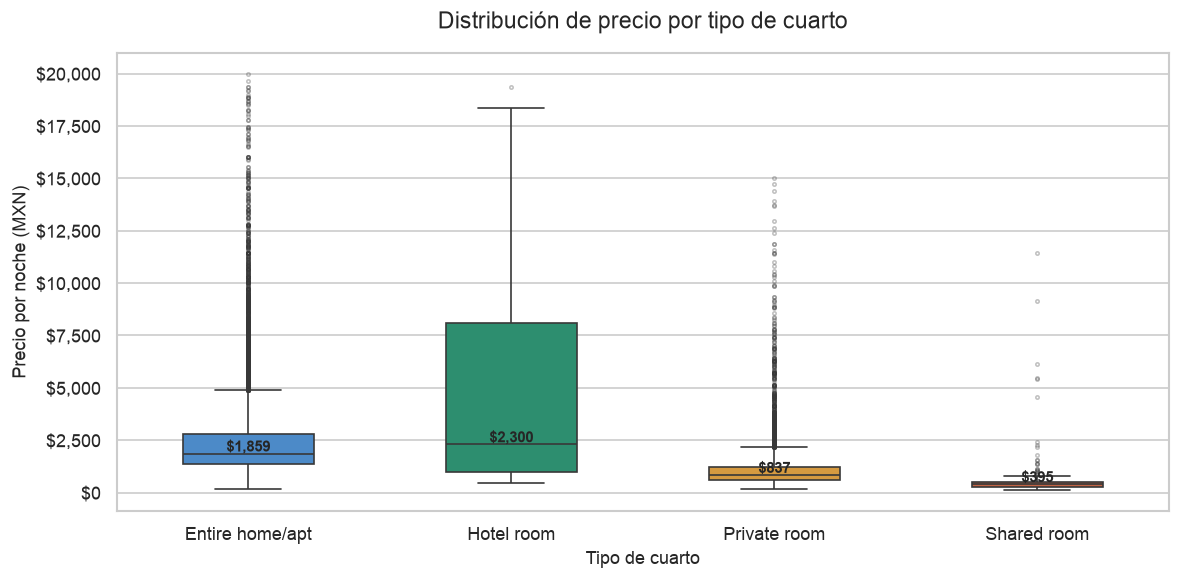

In [22]:
# Orden lógico: de mayor a menor precio típico
orden = ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
colores = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30']

fig, ax = plt.subplots(figsize=(10, 5))

df_box = df[df['room_type'].isin(orden)]

sns.boxplot(data=df_box, x='room_type', y='price',
            order=orden, palette=colores,
            width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=ax)

ax.set_title('Distribución de precio por tipo de cuarto', fontsize=14, pad=15)
ax.set_xlabel('Tipo de cuarto', fontsize=11)
ax.set_ylabel('Precio por noche (MXN)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Mediana encima de cada caja
for i, tipo in enumerate(orden):
    med = df[df['room_type'] == tipo]['price'].median()
    ax.text(i, med + 100, f'${med:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('graficas/03_precio_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

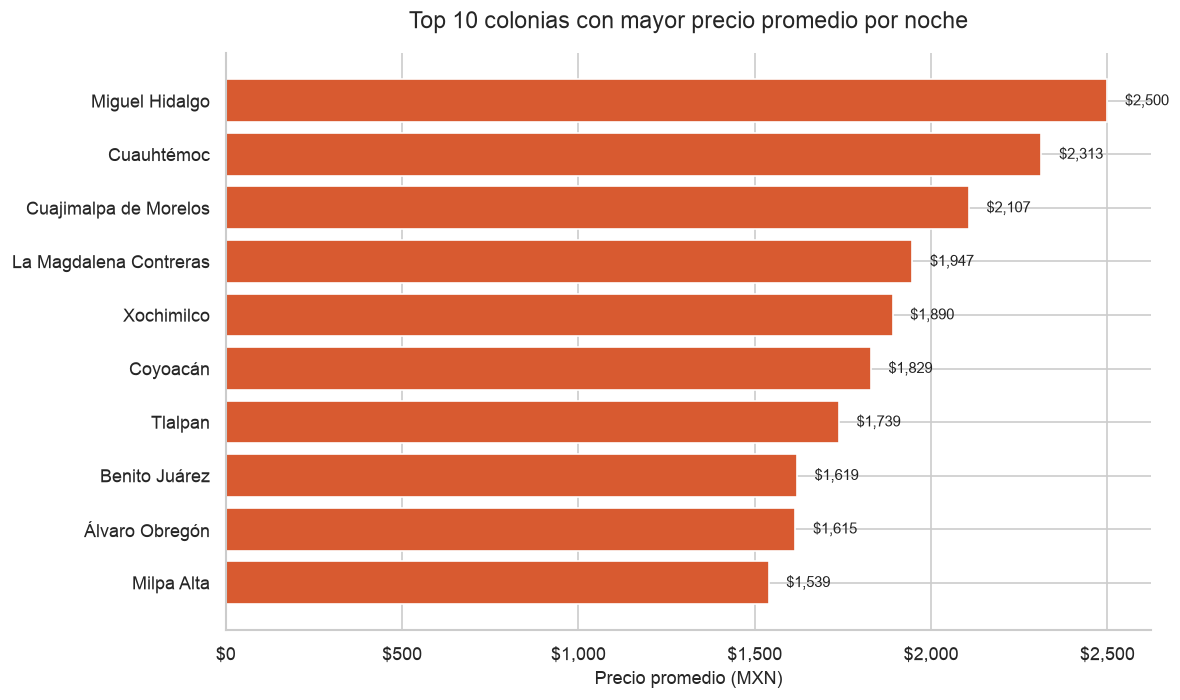

In [30]:
# Solo colonias con al menos 10 listings (evita promedios de 1 o 2 datos)
precio_colonia = (df.groupby('neighbourhood_cleansed')['price']
                  .agg(['mean', 'count'])
                  .query('count >= 10')
                  .sort_values('mean', ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(precio_colonia.index[::-1],
               precio_colonia['mean'].values[::-1],
               color='#D85A30')

for bar, val in zip(bars, precio_colonia['mean'].values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, color='#222222')

ax.set_title('Top 10 colonias con mayor precio promedio por noche', fontsize=14, pad=15)
ax.set_xlabel('Precio promedio (MXN)', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('graficas/04_colonias_mas_caras.png', dpi=150, bbox_inches='tight')
plt.show()

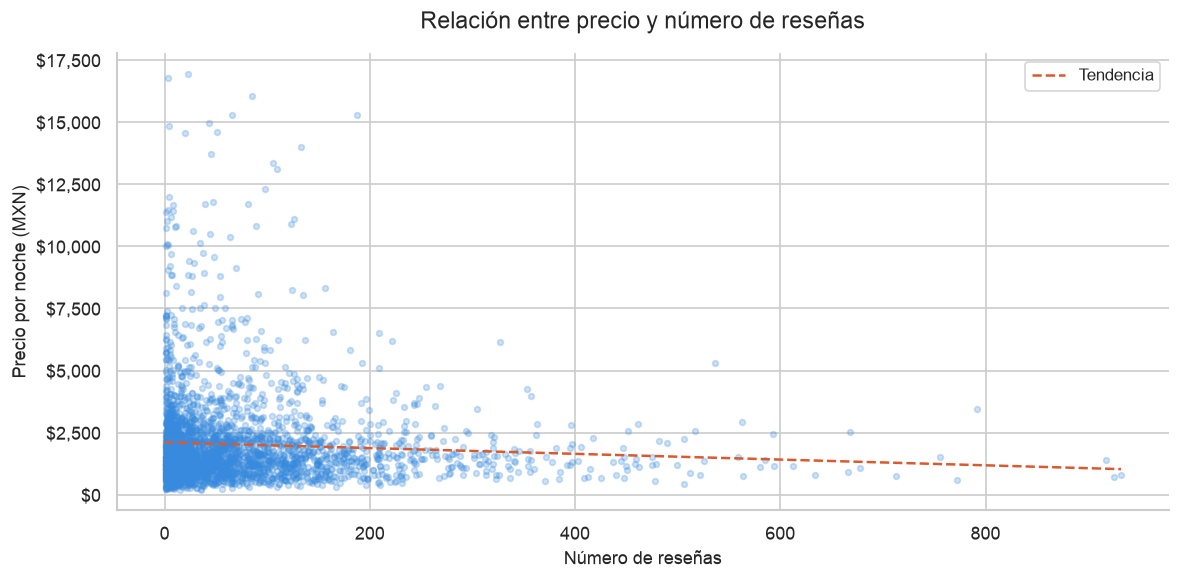

Correlación precio–reseñas: -0.063
Insight: correlación negativa débil → los listings más baratos tienden a tener más reseñas


In [31]:
# Filtramos listings con al menos 1 reseña para el scatter
df_scatter = df[df['number_of_reviews'] > 0].sample(n=3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))

scatter = ax.scatter(df_scatter['number_of_reviews'],
                     df_scatter['price'],
                     alpha=0.25, s=12, color='#378ADD')

ax.set_title('Relación entre precio y número de reseñas', fontsize=14, pad=15)
ax.set_xlabel('Número de reseñas', fontsize=11)
ax.set_ylabel('Precio por noche (MXN)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Línea de tendencia
import numpy as np
z = np.polyfit(df_scatter['number_of_reviews'], df_scatter['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df_scatter['number_of_reviews'].max(), 100)
ax.plot(x_line, p(x_line), color='#D85A30', linewidth=1.5,
        linestyle='--', label='Tendencia')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('graficas/05_precio_vs_resenas.png', dpi=150, bbox_inches='tight')
plt.show()

# El insight real
corr = df_scatter[['price','number_of_reviews']].corr().iloc[0,1]
print(f"Correlación precio–reseñas: {corr:.3f}")
print("Insight: correlación negativa débil → los listings más baratos tienden a tener más reseñas")

In [1]:
# Crea el archivo README.md vacío
with open('README.md', 'w') as f:
    f.write('# Análisis de Airbnb CDMX\n')

print("✅ README.md creado")

✅ README.md creado


In [1]:
import folium
from folium.plugins import HeatMap, MarkerCluster
import pandas as pd

df = pd.read_csv('data/listings_clean.csv')
print(f"✅ Folium {folium.__version__} listo — {len(df):,} listings cargados")

✅ Folium 0.20.0 listo — 22,256 listings cargados


In [2]:
# Centro del mapa = centro geográfico de CDMX
mapa = folium.Map(
    location=[19.4326, -99.1332],
    zoom_start=11,
    tiles='CartoDB positron'   # estilo limpio, ideal para portafolio
)

# Colores por tipo de cuarto
colores = {
    'Entire home/apt': '#378ADD',
    'Private room':    '#1D9E75',
    'Shared room':     '#EF9F27',
    'Hotel room':      '#D85A30'
}

# Muestreamos 2,000 listings para que el mapa no sea lento
df_muestra = df.sample(n=min(2000, len(df)), random_state=42)

for _, row in df_muestra.iterrows():
    color = colores.get(row['room_type'], '#888780')

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"""
            <b>{row['name'][:40]}</b><br>
            💰 ${row['price']:,.0f} MXN/noche<br>
            🏠 {row['room_type']}<br>
            📍 {row['neighbourhood_cleansed']}
            """,
            max_width=200
        )
    ).add_to(mapa)

mapa.save('graficas/mapa_cdmx.html')
print("✅ Mapa guardado — ábrelo en tu navegador para verlo")

✅ Mapa guardado — ábrelo en tu navegador para verlo


In [3]:
# Nuevo mapa solo con heatmap (más limpio visualmente)
mapa_calor = folium.Map(
    location=[19.4326, -99.1332],
    zoom_start=11,
    tiles='CartoDB dark_matter'  # fondo oscuro resalta el calor
)

# Preparamos los datos: lista de [lat, lon, peso]
# El peso es el precio — así las zonas caras brillan más
heat_data = df[['latitude', 'longitude', 'price']].dropna().values.tolist()

HeatMap(
    heat_data,
    min_opacity=0.3,
    max_zoom=13,
    radius=12,
    blur=10,
    gradient={0.2: '#1D9E75', 0.5: '#EF9F27', 0.8: '#D85A30', 1.0: '#FFFFFF'}
).add_to(mapa_calor)

# Título en el mapa
titulo = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     background: rgba(0,0,0,0.7); color: white; padding: 8px 20px;
     border-radius: 8px; font-family: sans-serif; font-size: 14px; z-index: 1000;">
    🔥 Densidad de listings Airbnb — CDMX
</div>
"""
mapa_calor.get_root().html.add_child(folium.Element(titulo))

mapa_calor.save('graficas/mapa_calor_cdmx.html')
print("✅ Mapa de calor guardado")

✅ Mapa de calor guardado


In [4]:
mapa_cluster = folium.Map(
    location=[19.4326, -99.1332],
    zoom_start=11,
    tiles='CartoDB positron'
)

cluster = MarkerCluster(
    options={'maxClusterRadius': 50}
).add_to(mapa_cluster)

# Aquí usamos TODOS los listings, no solo la muestra
for _, row in df.iterrows():
    precio_color = (
        '#1D9E75' if row['price'] < 800 else
        '#EF9F27' if row['price'] < 2000 else
        '#D85A30'
    )

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=precio_color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"""
            <b>{str(row['name'])[:40]}</b><br>
            💰 ${row['price']:,.0f} MXN/noche<br>
            ⭐ {row['review_scores_rating']:.1f} — {int(row['number_of_reviews'])} reseñas<br>
            🏠 {row['room_type']}<br>
            📍 {row['neighbourhood_cleansed']}
            """,
            max_width=220
        )
    ).add_to(cluster)

# Leyenda de colores
leyenda = """
<div style="position: fixed; bottom: 30px; left: 20px;
     background: white; padding: 12px 16px; border-radius: 8px;
     border: 1px solid #ccc; font-family: sans-serif; font-size: 12px; z-index: 1000;">
    <b>Precio por noche</b><br>
    <span style="color:#1D9E75">●</span> Menos de $800 MXN<br>
    <span style="color:#EF9F27">●</span> $800 – $2,000 MXN<br>
    <span style="color:#D85A30">●</span> Más de $2,000 MXN
</div>
"""
mapa_cluster.get_root().html.add_child(folium.Element(leyenda))

mapa_cluster.save('graficas/mapa_cluster_cdmx.html')
print("✅ Mapa de clusters guardado")
print(f"   Total de markers: {len(df):,}")

✅ Mapa de clusters guardado
   Total de markers: 22,256


In [5]:
from IPython.display import IFrame

# Muestra el mapa de clusters dentro del notebook
IFrame('graficas/mapa_cluster_cdmx.html', width=800, height=500)